# Raw Data Profiling
**BRIM Systems** | Prepared by: Brian Davis

---

## Purpose

Discovery-pass profiling against raw source system extracts. Findings from this notebook
inform the dbt staging models. It does not generate or modify any data.

**Scope:** Initial table orientation, schema listings, null rate analysis, data type
inference, and duplicate row analysis.

**Section flow:**
1. Configuration & Data Loading
2. Raw Table Summary — `head()` preview, row counts, key stats, data dictionary notes
3. Schema Listing & Null Flags — per-column dtype, null rate, distinct count
4. Format Consistency - detect inconsistencies across every string column
4. Data Type Inference — object column type assessment, suggested staging CASTs
5. Deduplication Analysis — duplicate classification, field agreement, temporal pattern

## 0. Environment Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import itertools
from collections import defaultdict

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.4f}".format)


BRAND_BLUE   = "#3D5166"
BRAND_ACCENT = "#6B8FA8"                    
WARN_AMBER   = "#D4881E"
FAIL_RED     = "#B94040"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#CCCCCC", "axes.grid": True,
    "grid.color": "#EEEEEE", "grid.linestyle": "-",
    "font.family": "sans-serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.dpi": 120,
})

print("Environment ready.")

Environment ready.


## 1. Data Loading

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
RAW_DIR = Path("../data/raw").resolve()

# ── Table name constants ──────────────────────────────────────────────────
TBL_MACHINES          = "machines"
TBL_OPERATORS         = "operators"
TBL_MATERIAL_LOTS     = "material_lots"
TBL_PART_CATALOG      = "part_catalog"
TBL_PRODUCTION_ORDERS = "production_orders"
TBL_INSPECTION_REC    = "inspection_records"
TBL_SCRAP_EVENTS      = "scrap_events"

# ── File paths (source_system_subfolder / filename.csv) ───────────────────
TABLES = {
    TBL_MACHINES:          RAW_DIR / "mes"       / f"{TBL_MACHINES}.csv",
    TBL_OPERATORS:         RAW_DIR / "hr"        / f"{TBL_OPERATORS}.csv",
    TBL_MATERIAL_LOTS:     RAW_DIR / "materials" / f"{TBL_MATERIAL_LOTS}.csv",
    TBL_PART_CATALOG:      RAW_DIR / "erp"       / f"{TBL_PART_CATALOG}.csv",
    TBL_PRODUCTION_ORDERS: RAW_DIR / "erp"       / f"{TBL_PRODUCTION_ORDERS}.csv",
    TBL_INSPECTION_REC:    RAW_DIR / "qms"       / f"{TBL_INSPECTION_REC}.csv",
    TBL_SCRAP_EVENTS:      RAW_DIR / "qms"       / f"{TBL_SCRAP_EVENTS}.csv",
}

# ── Load tables ───────────────────────────────────────────────────────────
dfs = {}
print(f"{'Table':<25} {'Rows':>8}  {'Cols':>5}  {'Size':>10}  Path")
print("-" * 85)

for name, path in TABLES.items():
    if not path.exists():
        print(f"  ✗  {name:<22} FILE NOT FOUND: {path}")
        continue
    df = pd.read_csv(path, low_memory=False)
    dfs[name] = df
    size_kb  = path.stat().st_size / 1024
    size_str = f"{size_kb/1024:.2f} MB" if size_kb > 1024 else f"{size_kb:.0f} KB"
    print(f"  ✓  {name:<22} {len(df):>8,}  {len(df.columns):>5}  {size_str:>10}  {path}")

Table                         Rows   Cols        Size  Path
-------------------------------------------------------------------------------------
  ✓  machines                      7      5        0 KB  /workspaces/portfolio/defects_scrap/data/raw/mes/machines.csv
  ✓  operators                    20      7        1 KB  /workspaces/portfolio/defects_scrap/data/raw/hr/operators.csv
  ✓  material_lots               920      8       66 KB  /workspaces/portfolio/defects_scrap/data/raw/materials/material_lots.csv
  ✓  part_catalog                 35      8        2 KB  /workspaces/portfolio/defects_scrap/data/raw/erp/part_catalog.csv
  ✓  production_orders         8,597     18     1.30 MB  /workspaces/portfolio/defects_scrap/data/raw/erp/production_orders.csv
  ✓  inspection_records        9,303     11      925 KB  /workspaces/portfolio/defects_scrap/data/raw/qms/inspection_records.csv
  ✓  scrap_events              7,948     17     1.20 MB  /workspaces/portfolio/defects_scrap/data/raw/qms/

## 2. Raw Table Summary

In [3]:
# head() preview — top 5 rows per table
for tbl, df in dfs.items():
    full_dups = df.duplicated(keep=False).sum()
    dup_str   = f"{full_dups:,}" if full_dups > 0 else "none"
    print(f"\n{'═'*70}")
    print(f"  {tbl.upper()}  ({len(df):,} rows  ×  {len(df.columns)} columns)  |  # of Full Duplications: {dup_str}")
    print(f"  Columns: {', '.join(df.columns.tolist())}")
    print(f"{'═'*70}")
    display(df.head())


══════════════════════════════════════════════════════════════════════
  MACHINES  (7 rows  ×  5 columns)  |  # of Full Duplications: none
  Columns: machine_id, machine_name, machine_type, age_years, location
══════════════════════════════════════════════════════════════════════


,machine_id,machine_name,machine_type,age_years,location
0,M01,Laser Cutter 1,Laser Cutting,3,Bay A
1,M02,Laser Cutter 2,Laser Cutting,8,Bay A
2,M03,Press Brake 1,Bending,12,Bay B
3,M04,Press Brake 2,Bending,2,Bay B
4,M05,Welding Station 1,Welding,6,Bay C



══════════════════════════════════════════════════════════════════════
  OPERATORS  (20 rows  ×  7 columns)  |  # of Full Duplications: none
  Columns: operator_id, operator_name, shift, hire_date, cert_level, specialization, welding_cert_current
══════════════════════════════════════════════════════════════════════


,operator_id,operator_name,shift,hire_date,cert_level,specialization,welding_cert_current
0,OP001,Allison Hill,Shift B,2026-03-26,Level 2,Welding,Yes
1,OP002,Noah Rhodes,Shift A,2022-01-14,Level 3,General,Yes
2,OP003,Angie Henderson,Shift B,2021-01-15,Level 2,General,Yes
3,OP004,Daniel Wagner,Shift A,2022-07-28,Level 2,Bending,Yes
4,OP005,Cristian Santos,Shift A,2024-06-21,Level 1,Bending,Yes



══════════════════════════════════════════════════════════════════════
  MATERIAL_LOTS  (920 rows  ×  8 columns)  |  # of Full Duplications: none
  Columns: lot_id_clean, lot_id_raw, supplier, material_type, receipt_date, cert_status, quantity_lbs, unit_cost_per_lb
══════════════════════════════════════════════════════════════════════


...

,work_order_id,part_number_raw,part_number_clean,customer,quantity_ordered,machine_id,operator_id_raw,operator_id_clean,shift_code,lot_id_raw,lot_id_clean,order_date,scheduled_start,actual_start,complexity,material_type,requires_welding,std_labor_hrs
0,WO-10000,P-1001,P-1001,Customer A,25,M07,OP007,OP007,NaN,NaN,NaN,2023-01-02,2023-01-02 14:08:00,2023-01-02 14:37:00,Medium,16ga Steel,True,1.0200
1,WO-10001,P-1032,P-1032,Customer F,152,M06,OP019,OP019,Shift A,NaN,NaN,2023-01-02,2023-01-02 07:14:00,2023-01-02 07:14:00,Medium,Aluminum 5052,False,2.0200
2,WO-10002,P-1010,P-1010,Customer A,59,M03,OP010,OP010,Shift B,NaN,NaN,2023-01-02,2023-01-02 14:22:00,2023-01-02 15:06:00,Low,Stainless 304,True,4.0800
3,WO-10003,P1016,P-1016,Customer G,434,M05,OP018,OP018,Shift A,LOT-1003,LOT-1003,2023-01-02,2023-01-02 06:19:00,2023-01-02 07:05:00,Low,14ga Steel,False,4.1300
4,WO-10004,PART-1012,P-1012,Customer D,453,M04,OP002,OP002,Shift A,NaN,NaN,2023-01-02,2023-01-02 06:30:00,2023-01-02 07:05:00,Medium,"3/8"" Plate",False,1.3900



══════════════════════════════════════════════════════════════════════
  INSPECTION_RECORDS  (9,303 rows  ×  11 columns)  |  # of Full Duplications: none
  Columns: inspection_id, work_order_id, inspection_date, inspector_id, quantity_inspected, quantity_passed, quantity_failed, defect_code_raw, defect_code_clean, disposition, notes
══════════════════════════════════════════════════════════════════════


,inspection_id,work_order_id,inspection_date,inspector_id,quantity_inspected,quantity_passed,quantity_failed,defect_code_raw,defect_code_clean,disposition,notes
0,INSP-1,WO-10000,2023-01-02 15:43:45.174234607,OP008,25,24,1,DIMENSIONAL,Dimensional,Rework,NaN
1,INSP-2,WO-10001,2023-01-02 08:58:55.133478901,OP008,152,139,13,weld def.,Weld Defect,Rework,NaN
2,INSP-3,WO-10002,2023-01-02 17:59:16.221099578,OP009,59,46,13,Dimension Error,Dimensional,Rework,NaN
3,INSP-4,WO-10003,2023-01-02 09:20:01.515735080,OP011,434,409,25,Porosity,Porosity,Scrap,Much section investment on gun young catch.
4,INSP-5,WO-10004,2023-01-02 11:42:55.478027044,OP018,453,433,20,Dimensional,Dimensional,Use-As-Is,NaN



══════════════════════════════════════════════════════════════════════
  SCRAP_EVENTS  (7,948 rows  ×  17 columns)  |  # of Full Duplications: none
  Columns: scrap_id, work_order_id, inspection_id, scrap_date, machine_id, operator_id, shift_code, material_type, lot_id, defect_code_clean, quantity_scrapped, quantity_reworked, scrap_reason_raw, scrap_reason_clean, material_cost_per_unit, labor_cost_per_unit, total_scrap_cost
══════════════════════════════════════════════════════════════════════


,scrap_id,work_order_id,inspection_id,scrap_date,machine_id,operator_id,shift_code,material_type,lot_id,defect_code_clean,quantity_scrapped,quantity_reworked,scrap_reason_raw,scrap_reason_clean,material_cost_per_unit,labor_cost_per_unit,total_scrap_cost
0,SCRAP-1,WO-10000,INSP-1,2023-01-02 15:43:45.174234607,M07,OP007,NaN,16ga Steel,NaN,Dimensional,0,1,First Article Fail,SETUP_ERROR,0.6900,20.1300,0.0000
1,SCRAP-2,WO-10001,INSP-2,2023-01-02 08:58:55.133478901,M06,OP019,Shift A,Aluminum 5052,NaN,Weld Defect,9,4,OPERATOR_ERROR,OPERATOR_ERROR,6.0600,35.0000,369.5400
2,SCRAP-3,WO-10002,INSP-3,2023-01-02 17:59:16.221099578,M03,OP010,Shift B,Stainless 304,NaN,Dimensional,4,9,Operator Error,OPERATOR_ERROR,2.1400,32.7900,139.7200
3,SCRAP-4,WO-10003,INSP-4,2023-01-02 09:20:01.515735080,M05,OP018,Shift A,14ga Steel,LOT-1003,Porosity,16,9,Mach Issue,MACHINE_ISSUE,8.6100,28.0700,586.8800
4,SCRAP-5,WO-10005,INSP-6,2023-01-02 18:25:00.019988300,M04,OP006,Shift B,"1/4"" Plate",LOT-1002,Burr,9,3,set up error,SETUP_ERROR,1.3000,49.3200,455.5800


---
## 3. Schema Listing & Null Flags

In [4]:
# ── Null thresholds ────────────────────────────────────────────────────────
NULL_WARN_PCT      = 0     # null rate % above which a column is flagged amber
NULL_FAIL_PCT      = 10.0  # null rate % above which a column is flagged red

KNOWN_VALUES = {}  # per-table expected value sets for future validation

In [5]:
null_flags = []

null_rows = []
for tbl, df in dfs.items():
    for col in df.columns:
        null_ct  = df[col].isna().sum()
        null_pct = null_ct / len(df) * 100
        if null_pct > 0:
            null_rows.append({"table": tbl, "column": col,
                               "null_count": null_ct, "null_pct": round(null_pct, 1)})
            if null_pct > NULL_WARN_PCT:
                null_flags.append({
                    "table": tbl, "column": col,
                    "null_pct": round(null_pct, 1),
                    "severity": "HIGH" if null_pct > NULL_FAIL_PCT else "MEDIUM",
                })

null_df = pd.DataFrame(null_rows)

# Schema inventory with null highlighting
def schema_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        null_ct  = s.isna().sum()
        null_pct = null_ct / len(df) * 100
        rows.append({
            "column":     col,
            "dtype":      str(s.dtype),
            "null_count": null_ct,
            "null_pct":   round(null_pct, 1),
            "n_unique":   s.nunique(dropna=True),
            "sample":     str(s.dropna().iloc[0])[:60] if null_ct < len(df) else "(all null)",
        })
    return pd.DataFrame(rows)

for tbl, df in dfs.items():
    sub = schema_summary(df, tbl)
    print(f"\n{'═'*70}\n  {tbl.upper()}\n{'═'*70}")
    display(
        sub.style
        .format({"null_pct": "{:.1f}%"})
        .applymap(
            lambda v: "background-color: #F8D7DA" if isinstance(v, float) and v > NULL_FAIL_PCT else
                      "background-color: #FFF3CD" if isinstance(v, float) and v > NULL_WARN_PCT else "",
            subset=["null_pct"]
        )
        .set_properties(**{"font-size": "11px"})
    )


══════════════════════════════════════════════════════════════════════
  MACHINES
══════════════════════════════════════════════════════════════════════


,column,dtype,null_count,null_pct,n_unique,sample
0,machine_id,object,0,0.0%,7,M01
1,machine_name,object,0,0.0%,7,Laser Cutter 1
2,machine_type,object,0,0.0%,4,Laser Cutting
3,age_years,int64,0,0.0%,7,3
4,location,object,0,0.0%,3,Bay A



══════════════════════════════════════════════════════════════════════
  OPERATORS
══════════════════════════════════════════════════════════════════════


,column,dtype,null_count,null_pct,n_unique,sample
0,operator_id,object,0,0.0%,20,OP001
1,operator_name,object,0,0.0%,20,Allison Hill
2,shift,object,0,0.0%,2,Shift B
3,hire_date,object,0,0.0%,20,2026-03-26
4,cert_level,object,0,0.0%,3,Level 2
5,specialization,object,0,0.0%,4,Welding
6,welding_cert_current,object,0,0.0%,2,Yes



══════════════════════════════════════════════════════════════════════
  MATERIAL_LOTS
══════════════════════════════════════════════════════════════════════


...

,column,dtype,null_count,null_pct,n_unique,sample
0,work_order_id,object,0,0.0%,8597,WO-10000
1,part_number_raw,object,0,0.0%,175,P-1001
2,part_number_clean,object,0,0.0%,35,P-1001
3,customer,object,0,0.0%,8,Customer A
4,quantity_ordered,int64,0,0.0%,491,25
5,machine_id,object,0,0.0%,7,M07
6,operator_id_raw,object,0,0.0%,40,OP007
7,operator_id_clean,object,0,0.0%,20,OP007
8,shift_code,object,815,9.5%,2,Shift A
9,lot_id_raw,object,1415,16.5%,863,LOT-1003



══════════════════════════════════════════════════════════════════════
  INSPECTION_RECORDS
══════════════════════════════════════════════════════════════════════


,column,dtype,null_count,null_pct,n_unique,sample
0,inspection_id,object,0,0.0%,9303,INSP-1
1,work_order_id,object,0,0.0%,8597,WO-10000
2,inspection_date,object,0,0.0%,9303,2023-01-02 15:43:45.174234607
3,inspector_id,object,0,0.0%,20,OP008
4,quantity_inspected,int64,0,0.0%,491,25
5,quantity_passed,int64,0,0.0%,477,24
6,quantity_failed,int64,0,0.0%,136,1
7,defect_code_raw,object,44,0.5%,54,DIMENSIONAL
8,defect_code_clean,object,157,1.7%,7,Dimensional
9,disposition,object,0,0.0%,4,Rework



══════════════════════════════════════════════════════════════════════
  SCRAP_EVENTS
══════════════════════════════════════════════════════════════════════


,column,dtype,null_count,null_pct,n_unique,sample
0,scrap_id,object,0,0.0%,7948,SCRAP-1
1,work_order_id,object,0,0.0%,7340,WO-10000
2,inspection_id,object,0,0.0%,7948,INSP-1
3,scrap_date,object,0,0.0%,7948,2023-01-02 15:43:45.174234607
4,machine_id,object,0,0.0%,7,M07
5,operator_id,object,0,0.0%,20,OP007
6,shift_code,object,749,9.4%,2,Shift A
7,material_type,object,0,0.0%,7,16ga Steel
8,lot_id,object,54,0.7%,871,LOT-1003
9,defect_code_clean,object,0,0.0%,7,Dimensional


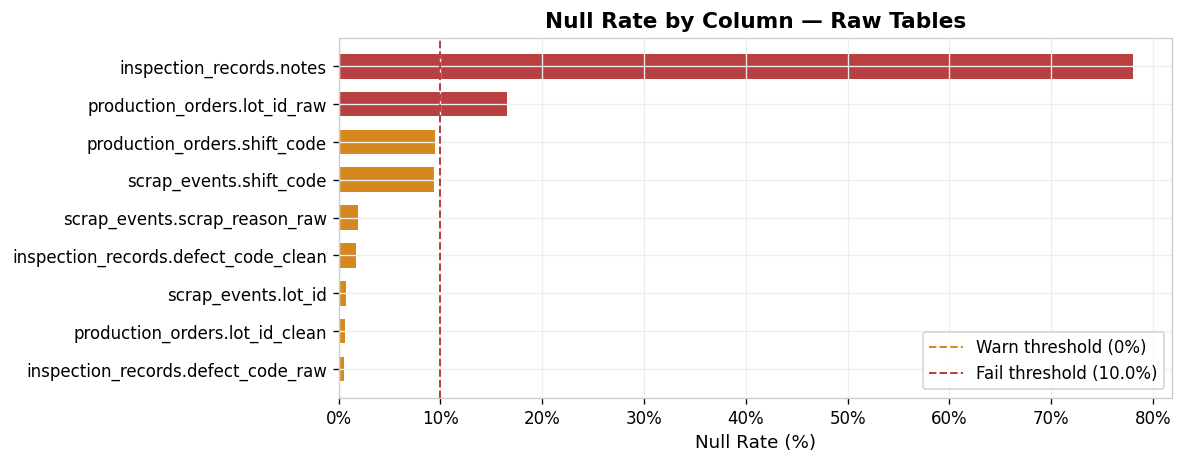


Flagged columns (null_pct ≥ 0%):


,table,column,null_pct,severity
0,production_orders,shift_code,9.5000,MEDIUM
1,production_orders,lot_id_raw,16.5000,HIGH
2,production_orders,lot_id_clean,0.6000,MEDIUM
3,inspection_records,defect_code_raw,0.5000,MEDIUM
4,inspection_records,defect_code_clean,1.7000,MEDIUM
5,inspection_records,notes,78.0000,HIGH
6,scrap_events,shift_code,9.4000,MEDIUM
7,scrap_events,lot_id,0.7000,MEDIUM
8,scrap_events,scrap_reason_raw,1.9000,MEDIUM


In [6]:
# Null rate bar chart — all columns with any nulls
if not null_df.empty:
    plot_df = null_df.sort_values("null_pct", ascending=True).copy()
    plot_df["label"] = plot_df["table"] + "." + plot_df["column"]
    colors = [
        FAIL_RED   if v >= NULL_FAIL_PCT else
        WARN_AMBER if v >= NULL_WARN_PCT else
        BRAND_ACCENT
        for v in plot_df["null_pct"]
    ]
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.38)))
    ax.barh(plot_df["label"], plot_df["null_pct"], color=colors, height=0.65)
    ax.axvline(NULL_WARN_PCT, color=WARN_AMBER, linestyle="--", linewidth=1.2,
               label=f"Warn threshold ({NULL_WARN_PCT}%)")
    ax.axvline(NULL_FAIL_PCT, color=FAIL_RED,   linestyle="--", linewidth=1.2,
               label=f"Fail threshold ({NULL_FAIL_PCT}%)")
    ax.set_xlabel("Null Rate (%)")
    ax.set_title("Null Rate by Column — Raw Tables")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    if null_flags:
        print(f"\nFlagged columns (null_pct ≥ {NULL_WARN_PCT}%):")
        display(pd.DataFrame(null_flags).reset_index(drop=True))

## 4. Format Consistency

Automated scan across every string column in every raw table. Detects two
classes of inconsistency that must be resolved in staging models:

- **Case variants** — same logical value stored in mixed case
- **Whitespace** — leading or trailing spaces 


In [7]:
consistency_flags = []

for tbl, df in dfs.items():
    known = KNOWN_VALUES.get(tbl, {})
    for col in df.select_dtypes(include="object").columns:
        s = df[col].dropna().astype(str)
        if len(s) == 0:
            continue
        n_distinct = s.nunique()
        issues     = []
        detail     = {}

        # ── Case inconsistency ────────────────────────────────────────────
        lowered    = s.str.lower()
        n_lower    = lowered.nunique()
        if n_lower < n_distinct:
            # For each canonical (lowercased) value that has multiple casings,
            # show each variant and its row count
            case_groups = {}
            for canonical in lowered.unique():
                variants = s[lowered == canonical].value_counts()
                if len(variants) > 1:
                    case_groups[canonical] = variants.to_dict()
            issues.append(
                f"case variants (collapsible: {n_distinct - n_lower})"
            )
            detail["case_groups"] = case_groups

        # ── Whitespace ────────────────────────────────────────────────────
        ws_mask  = s != s.str.strip()
        ws_count = ws_mask.sum()
        if ws_count:
            ws_examples = s[ws_mask].value_counts().head(5).to_dict()
            issues.append(f"whitespace ({ws_count:,} rows)")
            detail["whitespace_examples"] = ws_examples

        if issues:
            consistency_flags.append({
                "table":      tbl,
                "column":     col,
                "n_distinct": n_distinct,
                "issues":     "; ".join(issues),
                "sample":     str(s.unique()[:3].tolist()),
                "_detail":    detail,
            })

consistency_flag_df = pd.DataFrame(consistency_flags)

if consistency_flag_df.empty:
    print("No format inconsistencies detected.")
else:
    print(f"Flagged columns: {len(consistency_flag_df)} across "
          f"{consistency_flag_df['table'].nunique()} tables\n")

    def _row_color(row):
        issues = row["issues"]
        if "unknown values" in issues:
            return ["background-color: #F8D7DA"] * len(row)
        if any(x in issues for x in ["case", "whitespace"]):
            return ["background-color: #FFF3CD"] * len(row)
        return [""] * len(row)

    display(
        consistency_flag_df
        .drop(columns=["_detail"])
        .style
        .apply(_row_color, axis=1)
        .set_properties(**{"font-size": "11px"})
        .hide(axis="index")
    )

    # ── Detailed breakdown per flagged column ─────────────────────────────
    for _, row in consistency_flag_df.iterrows():
        detail = row["_detail"]
        if not detail:
            continue

        print(f"\n{'─'*60}")
        print(f"  {row['table']}.{row['column']}")
        print(f"{'─'*60}")

        if "case_groups" in detail:
            print(f"\n  Case variant groups "
                  f"({len(detail['case_groups'])} canonical values "
                  f"with multiple casings):\n")
            for canonical, variants in detail["case_groups"].items():
                total = sum(variants.values())
                print(f"  '{canonical}'  ({total:,} rows total)")
                for variant, count in sorted(
                    variants.items(), key=lambda x: -x[1]
                ):
                    pct = count / len(dfs[row["table"]]) * 100
                    print(f"    '{variant}'  →  {count:,} rows  ({pct:.1f}%)")

        if "whitespace_examples" in detail:
            print(f"\n  Values with leading/trailing whitespace:\n")
            for val, count in detail["whitespace_examples"].items():
                print(f"    '{val}'  →  {count:,} rows")

Flagged columns: 3 across 3 tables



table,column,n_distinct,issues,sample
production_orders,part_number_raw,175,case variants (collapsible: 35),"['P-1001', 'P-1032', 'P-1010']"
inspection_records,defect_code_raw,54,case variants (collapsible: 17),"['DIMENSIONAL', 'weld def.', 'Dimension Error']"
scrap_events,scrap_reason_raw,37,case variants (collapsible: 6),"['First Article Fail', 'OPERATOR_ERROR', 'Operator Error']"



────────────────────────────────────────────────────────────
  production_orders.part_number_raw
────────────────────────────────────────────────────────────

  Case variant groups (35 canonical values with multiple casings):

  'p-1001'  (144 rows total)
    'P-1001'  →  128 rows  (1.5%)
    'p-1001'  →  16 rows  (0.2%)
  'p-1032'  (160 rows total)
    'P-1032'  →  136 rows  (1.6%)
    'p-1032'  →  24 rows  (0.3%)
  'p-1010'  (165 rows total)
    'P-1010'  →  127 rows  (1.5%)
    'p-1010'  →  38 rows  (0.4%)
  'p-1029'  (164 rows total)
    'P-1029'  →  143 rows  (1.7%)
    'p-1029'  →  21 rows  (0.2%)
  'p-1003'  (177 rows total)
    'P-1003'  →  151 rows  (1.8%)
    'p-1003'  →  26 rows  (0.3%)
  'p-1021'  (173 rows total)
    'P-1021'  →  151 rows  (1.8%)
    'p-1021'  →  22 rows  (0.3%)
  'p-1019'  (156 rows total)
    'P-1019'  →  128 rows  (1.5%)
    'p-1019'  →  28 rows  (0.3%)
  'p-1008'  (152 rows total)
    'P-1008'  →  128 rows  (1.5%)
    'p-1008'  →  24 rows  (0.3%)
  'p

---
## 5. Data Type Inference (Object Columns Only)

Runs only on `object`-typed columns. Pandas defaults any ambiguous or mixed column
to `object` on CSV load, so these are the only columns that may need explicit
`CAST()` in staging. Non-object columns (`int64`, `float64`, `bool`) are accepted as-is.

Manual overrides in `DTYPE_OVERRIDES` take priority over auto-inference
for columns where the inference would be wrong (e.g., numeric ID fields, 0/1 booleans).

In [8]:
# ── Manual dtype overrides ────────────────────────────────────────────────
DTYPE_OVERRIDES = {
    TBL_MACHINES: {
        "age_years": "numeric",
    },
    TBL_PRODUCTION_ORDERS: {
        "quantity_ordered": "numeric",
        "std_labor_hrs":    "numeric",
        "requires_welding": "boolean",
    },
    TBL_INSPECTION_REC: {
        "quantity_inspected": "numeric",
        "quantity_passed":    "numeric",
        "quantity_failed":    "numeric",
    },
    TBL_SCRAP_EVENTS: {
        "quantity_scrapped":      "numeric",
        "quantity_reworked":      "numeric",
        "material_cost_per_unit": "numeric",
        "labor_cost_per_unit":    "numeric",
        "total_scrap_cost":       "numeric",
    },
    TBL_MATERIAL_LOTS: {
        "quantity_lbs":     "numeric",
        "unit_cost_per_lb": "numeric",
    },
}

# ── Thresholds ────────────────────────────────────────────────
NUMERIC_INFER_PCT  = 80.0  # % of values parseable as numeric to infer type
DATETIME_INFER_PCT = 80.0  # % of values parseable as datetime to infer type

In [9]:
def infer_column_type(series: pd.Series) -> tuple[str, float]:
    """
    Attempt to infer the intended type of an object-typed column.
    Returns (inferred_type, confidence_pct).
    Possible types: 'numeric', 'datetime', 'boolean', 'categorical', 'id', 'text'
    """
    s = series.dropna().astype(str)
    if len(s) == 0:
        return "unknown", 0.0
    n = len(s)

    # Boolean check — only 2 distinct values matching known boolean patterns
    bool_sets = [
        {"true", "false"}, {"yes", "no"}, {"y", "n"}, {"1", "0"}, {"t", "f"}
    ]
    lower_vals = set(s.str.lower().unique())
    if any(lower_vals <= bs for bs in bool_sets):
        return "boolean", 100.0

    # Numeric check
    numeric_ok = pd.to_numeric(s, errors="coerce").notna().sum() / n * 100
    if numeric_ok >= NUMERIC_INFER_PCT:
        return "numeric", round(numeric_ok, 1)

    # Datetime check
    dt_ok = pd.to_datetime(s, errors="coerce", infer_datetime_format=True).notna().sum() / n * 100
    if dt_ok >= DATETIME_INFER_PCT:
        return "datetime", round(dt_ok, 1)

    # Low-cardinality categorical
    if s.nunique() <= 15:
        return "categorical", 100.0

    return "text", 100.0


dtype_flags = []

for tbl, df in dfs.items():
    overrides = DTYPE_OVERRIDES.get(tbl, {})
    for col in df.columns:
        current = str(df[col].dtype)

        # Apply manual override if present
        if col in overrides:
            intended = overrides[col]
            confidence = 100.0
            source = "override"
        elif current == "object":
            intended, confidence = infer_column_type(df[col])
            source = "inferred"
        else:
            continue  # pandas inferred a non-object type — accept it

        # Flag if inferred type differs from current
        type_ok = (
            (intended == "numeric"     and current in ("int64", "float64")) or
            (intended == "boolean"     and current == "bool") or
            (intended == "datetime"    and "datetime" in current) or
            (intended == "categorical" and current == "category") or
            (intended == "text"        and current == "object") or
            (intended == "id"          and current == "object")
        )
        if not type_ok:
            dtype_flags.append({
                "table":        tbl,
                "column":       col,
                "current_type": current,
                "intended_type": intended,
                "confidence":   f"{confidence:.0f}%",
                "source":       source,
                "staging_cast": {
                    "numeric":     "CAST(col AS NUMERIC)",
                    "datetime":    "CAST(col AS TIMESTAMP)",
                    "boolean":     "CAST(col AS BOOLEAN)",
                    "categorical": "consider enum or varchar",
                    "text":        "already object; no cast needed",
                    "id":          "ID field; keep as varchar",
                }.get(intended, ""),
            })

dtype_flag_df = pd.DataFrame(dtype_flags)

if dtype_flag_df.empty:
    print("No type mismatches detected.")
else:
    print(f"Type mismatches flagged: {len(dtype_flag_df)} columns across "
          f"{dtype_flag_df['table'].nunique()} tables\n")
    display(
        dtype_flag_df.style
        .applymap(
            lambda v: "background-color: #FFF3CD" if v == "inferred" else
                      "background-color: #D4EDDA" if v == "override" else "",
            subset=["source"]
        )
        .set_properties(**{"font-size": "11px"})
        .hide(axis="index")
    )

Type mismatches flagged: 34 columns across 7 tables



table,column,current_type,intended_type,confidence,source,staging_cast
machines,machine_id,object,categorical,100%,inferred,consider enum or varchar
machines,machine_name,object,categorical,100%,inferred,consider enum or varchar
machines,machine_type,object,categorical,100%,inferred,consider enum or varchar
machines,location,object,categorical,100%,inferred,consider enum or varchar
operators,shift,object,categorical,100%,inferred,consider enum or varchar
operators,hire_date,object,datetime,100%,inferred,CAST(col AS TIMESTAMP)
operators,cert_level,object,categorical,100%,inferred,consider enum or varchar
operators,specialization,object,categorical,100%,inferred,consider enum or varchar
operators,welding_cert_current,object,boolean,100%,inferred,CAST(col AS BOOLEAN)
material_lots,supplier,object,categorical,100%,inferred,consider enum or varchar


---
## 6. Deduplication Analysis

Duplicate rows require a staging decision, but the right decision depends on
understanding what *kind* of duplicate each occurrence is. This section runs
two tolerance-level checks on every table automatically — no configuration
beyond `IGNORE_COLS` in Section 1 is required.

**Columns excluded from comparison** are defined in `IGNORE_COLS` (Section 1).
These are columns expected to differ between otherwise identical rows and which
should not be used to distinguish genuine records: 

- Primary keys      — auto-incremented by the source system on every
                       insert, so always unique even on re-entry

- Foreign keys      — occasionally re-assigned on re-entry when the
                       parent record is also recreated

- Timestamps        — source systems often log a new timestamp on
                       re-entry rather than copying the original,
                       producing minor jitter that masks content duplication

- Sequence fields   — any field the system auto-populates independently
                       of the user (batch numbers, import IDs, row versions) 

**Tolerance 0 — Full content duplicates:** Every non-ignored column is identical.
Safe to deduplicate with `SELECT DISTINCT *` on content columns, or
`ROW_NUMBER() OVER (PARTITION BY <ignored_cols> ORDER BY <pk>) = 1`.

**Tolerance 1 — One content column differs:** All non-ignored columns match
except exactly one. The output groups results by which column is the differing
one — multiple distinct columns may each independently account for some portion
of near-duplicates. This catches cases where a single content field was entered
slightly differently on re-entry.

**5a — Overall summary:** Row counts and rates per table and tolerance level.

**5b — Drill-down:** For each flagged table, a statistical difference summary
across all duplicate groups and a representative sample of 5 groups.

### 5a. Overall Duplicate Summary

In [10]:
# ── Columns to ignore in duplicate analysis ───────────────────────────────
# Defines per-table columns excluded from duplicate content comparison.
# Include any column expected to differ between otherwise identical rows
# and which should not be used to distinguish genuine records, including 
# Primary keys, Foreign keys, Timestamps and other Sequence fields

IGNORE_COLS = {
    TBL_MACHINES:          ["machine_id"],
    TBL_OPERATORS:         ["operator_id"],
    TBL_MATERIAL_LOTS:     ["lot_id_clean"],
    TBL_PART_CATALOG:      ["part_number"],
    TBL_PRODUCTION_ORDERS: ["work_order_id"],
    TBL_INSPECTION_REC:    ["inspection_id", "inspection_date"],
    TBL_SCRAP_EVENTS:      ["scrap_id"],
}

# ── Duplicate analysis configuration ─────────────────────────────────────
DUP_TOLERANCE_LEVELS = [0, 1]   # 0 = exact content match, 1 = 1-col diff
DUP_STRING_CASE      = False    # False = case-insensitive string comparison
DUP_RATE_THRESHOLD   = 0.0     # flag any table with duplicates above this rate

In [11]:
def normalize_value(val, case_insensitive=True):
    """Normalize a single value to a comparable string."""
    if pd.isna(val):
        return "__null__"
    if isinstance(val, str) and case_insensitive:
        return val.strip().lower()
    return str(val)


def get_content_cols(df, tbl):
    """
    Return (ignored_cols, content_cols) for a table.
    Ignored columns are excluded from all duplicate comparisons.
    Content columns are the columns used for fingerprinting.
    """
    ignored      = IGNORE_COLS.get(tbl, [])
    content_cols = [c for c in df.columns if c not in ignored]
    return ignored, content_cols


def fingerprint_rows(df, content_cols, exclude=None):
    """
    Compute a fingerprint for each row using content_cols,
    optionally excluding additional columns.
    """
    cols_to_use = [c for c in content_cols if c not in (exclude or [])]
    return df[cols_to_use].apply(
        lambda row: "|".join(
            f"{c}={normalize_value(row[c], DUP_STRING_CASE)}"
            for c in cols_to_use
        ),
        axis=1,
    )


def find_dupes_at_tolerance(df, tbl, tolerance):
    """
    Find rows where exactly `tolerance` content columns differ,
    with all other content columns identical.
    Columns in IGNORE_COLS are always excluded from comparison.
    Supported tolerance levels: 0 and 1.
    """
    ignored, content_cols = get_content_cols(df, tbl)
    total = len(df)

    # ── Tolerance 0: exact content duplicates ─────────────────────────────
    if tolerance == 0:
        fp       = fingerprint_rows(df, content_cols)
        dup_mask = fp.duplicated(keep=False)
        count    = dup_mask.sum()
        if count == 0:
            return pd.DataFrame()
        return pd.DataFrame([{
            "differing_cols": "(none — full content duplicate)",
            "dup_rows":       count,
            "dup_pct":        round(count / total * 100, 2),
        }])

    # ── Tolerance 1: exactly 1 content column differs ─────────────────────
    elif tolerance == 1:
        exact_fp   = fingerprint_rows(df, content_cols)
        exact_mask = exact_fp.duplicated(keep=False)

        results = {}
        for col in content_cols:
            fp       = fingerprint_rows(df, content_cols, exclude=[col])
            dup_mask = fp.duplicated(keep=False)
            true_t1  = dup_mask & ~exact_mask
            idx_set  = frozenset(df[true_t1].index)
            if idx_set:
                results[col] = idx_set

        if not results:
            return pd.DataFrame()

        rows = []
        for col, idx_set in sorted(results.items(), key=lambda x: -len(x[1])):
            rows.append({
                "differing_cols": col,
                "dup_rows":       len(idx_set),
                "dup_pct":        round(len(idx_set) / total * 100, 2),
            })
        return pd.DataFrame(rows)

    return pd.DataFrame()


# ── Run across all tables ─────────────────────────────────────────────────
print("=" * 70)
print("DUPLICATE ROW ANALYSIS")
print("Columns in IGNORE_COLS excluded from all comparisons (see Section 1)")
print("Tolerance 0: all content columns identical")
print("Tolerance 1: exactly 1 content column differs")
print(f"String comparison: case-{'in' if not DUP_STRING_CASE else ''}sensitive")
print("=" * 70)

for tbl, df in dfs.items():
    ignored, content_cols = get_content_cols(df, tbl)
    total                 = len(df)

    print(f"\n── {tbl.upper()}  ({total:,} rows)")
    print(f"   Ignored: {ignored or '(none)'}  |  "
          f"Content columns checked: {len(content_cols)}")

    any_flagged = False

    for tol in DUP_TOLERANCE_LEVELS:
        result_df = find_dupes_at_tolerance(df, tbl, tol)

        label = (
            "Tolerance 0 — full content duplicates (all cols match)"
            if tol == 0 else
            "Tolerance 1 — exactly 1 content column differs"
        )

        if result_df.empty:
            print(f"  {label}: none detected")
        else:
            total_dup_rows = result_df["dup_rows"].sum()
            total_dup_pct  = round(total_dup_rows / total * 100, 2)
            flag           = "  ⚠" if total_dup_pct > DUP_RATE_THRESHOLD else ""
            any_flagged    = True

            print(f"  {label}: {total_dup_rows:,} rows "
                  f"({total_dup_pct:.2f}%){flag}")
            display(
                result_df.style
                .format({"dup_rows": "{:,}", "dup_pct": "{:.2f}%"})
                .applymap(
                    lambda v: "background-color: #F8D7DA; font-weight: bold"
                              if isinstance(v, float) and v > DUP_RATE_THRESHOLD else
                              "background-color: #FFF3CD"
                              if isinstance(v, float) and v > 0 else "",
                    subset=["dup_pct"]
                )
                .set_properties(**{"font-size": "11px"})
                .hide(axis="index")
            )

    if not any_flagged:
        print("  No duplicates detected at any tolerance level.")

DUPLICATE ROW ANALYSIS
Columns in IGNORE_COLS excluded from all comparisons (see Section 1)
Tolerance 0: all content columns identical
Tolerance 1: exactly 1 content column differs
String comparison: case-insensitive

── MACHINES  (7 rows)
   Ignored: ['machine_id']  |  Content columns checked: 4
  Tolerance 0 — full content duplicates (all cols match): none detected
  Tolerance 1 — exactly 1 content column differs: none detected
  No duplicates detected at any tolerance level.

── OPERATORS  (20 rows)
   Ignored: ['operator_id']  |  Content columns checked: 6
  Tolerance 0 — full content duplicates (all cols match): none detected
  Tolerance 1 — exactly 1 content column differs: none detected
  No duplicates detected at any tolerance level.

── MATERIAL_LOTS  (920 rows)
   Ignored: ['lot_id_clean']  |  Content columns checked: 7
  Tolerance 0 — full content duplicates (all cols match): none detected


  Tolerance 1 — exactly 1 content column differs: none detected
  No duplicates detected at any tolerance level.

── PART_CATALOG  (35 rows)
   Ignored: ['part_number']  |  Content columns checked: 7
  Tolerance 0 — full content duplicates (all cols match): none detected
  Tolerance 1 — exactly 1 content column differs: none detected
  No duplicates detected at any tolerance level.

── PRODUCTION_ORDERS  (8,597 rows)
   Ignored: ['work_order_id']  |  Content columns checked: 17


  Tolerance 0 — full content duplicates (all cols match): none detected


  Tolerance 1 — exactly 1 content column differs: none detected
  No duplicates detected at any tolerance level.

── INSPECTION_RECORDS  (9,303 rows)
   Ignored: ['inspection_id', 'inspection_date']  |  Content columns checked: 9


  Tolerance 0 — full content duplicates (all cols match): 1,094 rows (11.76%)  ⚠


...

  Tolerance 1 — exactly 1 content column differs: 10 rows (0.11%)  ⚠


differing_cols,dup_rows,dup_pct
work_order_id,10,0.11%



── SCRAP_EVENTS  (7,948 rows)
   Ignored: ['scrap_id']  |  Content columns checked: 16


  Tolerance 0 — full content duplicates (all cols match): none detected


  Tolerance 1 — exactly 1 content column differs: none detected
  No duplicates detected at any tolerance level.


In [12]:
# ── Section 5b: Drill-down on flagged duplicate groups ───────────────────
SAMPLE_GROUPS = 5

for tbl, df in dfs.items():
    ignored, content_cols = get_content_cols(df, tbl)

    for tol in DUP_TOLERANCE_LEVELS:
        result_df = find_dupes_at_tolerance(df, tbl, tol)
        if result_df.empty:
            continue

        total_dup_rows = result_df["dup_rows"].sum()
        if total_dup_rows == 0:
            continue

        print(f"\n{'═'*70}")
        print(f"  {tbl.upper()} — Tolerance {tol} drill-down")
        print(f"  Ignored: {ignored or '(none)'}  |  "
              f"Flagged rows: {total_dup_rows:,}")
        print(f"{'═'*70}")

        for _, res_row in result_df.iterrows():
            diff_col_label = res_row["differing_cols"]
            print(f"\n  Differing column: {diff_col_label}  "
                  f"({res_row['dup_rows']:,} rows, {res_row['dup_pct']:.2f}%)")

            # ── Reconstruct flagged rows ──────────────────────────────────
            if tol == 0:
                fp       = fingerprint_rows(df, content_cols)
                dup_mask = fp.duplicated(keep=False)
            else:
                col      = diff_col_label
                exact_fp = fingerprint_rows(df, content_cols)
                exact_m  = exact_fp.duplicated(keep=False)
                fp       = fingerprint_rows(df, content_cols, exclude=[col])
                dup_mask = fp.duplicated(keep=False) & ~exact_m

            df_flagged        = df[dup_mask].copy()
            df_flagged["_fp"] = fp[dup_mask].values

            # ── Part 1: Difference summary ────────────────────────────────
            n_groups = df_flagged["_fp"].nunique()
            print(f"\n  ── Part 1: Difference summary across "
                  f"{n_groups:,} duplicate groups")

            summary_rows = []
            for col in content_cols:
                groups = df_flagged.groupby("_fp")[col].apply(list)
                groups = groups[groups.apply(len) >= 2]
                if groups.empty:
                    continue

                if pd.api.types.is_numeric_dtype(df[col]):
                    diffs = groups.apply(
                        lambda vals: max(vals) - min(vals)
                        if all(pd.notna(v) for v in vals) else None
                    ).dropna()
                    if diffs.empty:
                        continue
                    pct_agree = round((diffs == 0).mean() * 100, 1)
                    summary_rows.append({
                        "column":        col,
                        "type":          "numeric",
                        "pct_identical": f"{pct_agree:.1f}%",
                        "mean_diff":     round(float(diffs.mean()), 4),
                        "max_diff":      round(float(diffs.max()), 4),
                        "p95_diff":      round(float(diffs.quantile(0.95)), 4),
                        "note": (
                            "always identical" if pct_agree == 100 else
                            "minor variation"  if float(diffs.max()) <= 2 else
                            "meaningful variation — review before deduplicating"
                        ),
                    })
                else:
                    try:
                        parsed = pd.to_datetime(df[col], errors="coerce")
                        if parsed.notna().mean() > 0.8:
                            diffs = groups.apply(
                                lambda vals: abs(
                                    (pd.to_datetime(vals[0]) -
                                     pd.to_datetime(vals[1])).total_seconds() / 60
                                ) if len(vals) >= 2 else None
                            ).dropna()
                            pct_agree = round((diffs == 0).mean() * 100, 1)
                            summary_rows.append({
                                "column":        col,
                                "type":          "datetime",
                                "pct_identical": f"{pct_agree:.1f}%",
                                "mean_diff":     f"{diffs.mean():.1f} min",
                                "max_diff":      f"{diffs.max():.1f} min",
                                "p95_diff":      f"{diffs.quantile(0.95):.1f} min",
                                "note": (
                                    "always identical" if pct_agree == 100 else
                                    "minor variation"
                                    if float(diffs.max()) <= 120 else
                                    "meaningful variation — review before deduplicating"
                                ),
                            })
                            continue
                    except Exception:
                        pass

                    disagree = groups.apply(
                        lambda vals: len({
                            str(v).strip().lower() for v in vals
                            if pd.notna(v)
                        }) > 1
                    )
                    pct_agree = round((~disagree).mean() * 100, 1)
                    sample_val = (
                        df_flagged.groupby("_fp")[col]
                        .apply(lambda x: " → ".join(
                            x.astype(str).unique()[:2].tolist()
                        ))
                        .iloc[0] if not df_flagged.empty else ""
                    )
                    summary_rows.append({
                        "column":        col,
                        "type":          "string",
                        "pct_identical": f"{pct_agree:.1f}%",
                        "mean_diff":     "—",
                        "max_diff":      "—",
                        "p95_diff":      f"e.g. {sample_val}",
                        "note": (
                            "always identical" if pct_agree == 100 else
                            "varies — review before deduplicating"
                        ),
                    })

            if summary_rows:
                summary_df = (
                    pd.DataFrame(summary_rows)
                    .sort_values("pct_identical")
                )
                display(
                    summary_df.style
                    .applymap(
                        lambda v: "background-color: #F8D7DA"
                                  if isinstance(v, str) and "meaningful" in v else
                                  "background-color: #FFF3CD"
                                  if isinstance(v, str) and "varies" in v else
                                  "background-color: #D4EDDA"
                                  if isinstance(v, str) and "identical" in v else "",
                        subset=["note"]
                    )
                    .set_properties(**{"font-size": "11px"})
                    .hide(axis="index")
                )

            # ── Part 2: Representative sample ─────────────────────────────
            print(f"\n  ── Part 2: Sample of {SAMPLE_GROUPS} duplicate groups")

            sample_fps = df_flagged["_fp"].unique()[:SAMPLE_GROUPS]
            sample_out = []
            for i, fp_val in enumerate(sample_fps, start=1):
                idx   = df_flagged.index[df_flagged["_fp"] == fp_val]
                group = df.loc[idx].copy()
                group.insert(0, "dup_group", i)
                group.insert(1, "raw_row_number", group.index.tolist())
                sample_out.append(group)

            if sample_out:
                display(
                    pd.concat(sample_out).style
                    .applymap(
                        lambda v: "background-color: #F0F4F8"
                                  if isinstance(v, int) and v % 2 == 1 else
                                  "background-color: #FFF3CD"
                                  if isinstance(v, int) and v % 2 == 0 else "",
                        subset=["dup_group"]
                    )
                    .set_properties(**{"font-size": "10px"})
                    .hide(axis="index")
                )

            # ── Staging recommendation ────────────────────────────────────
            print(f"\n  ── Staging recommendation")
            has_meaningful = any(
                "meaningful" in r.get("note", "") or
                "varies"     in r.get("note", "")
                for r in summary_rows
            )
            if tol == 0:
                print("  → SELECT DISTINCT * is safe — all content columns "
                      "are identical.")
            elif not has_meaningful:
                print("  → ROW_NUMBER() OVER (PARTITION BY <business_key> "
                      "ORDER BY <pk> ASC) = 1 is safe.")
                print("     All content variation is minor (timestamp jitter "
                      "or +-1-2 numeric). First entry is authoritative.")
            else:
                print("  → Review required before deduplicating.")
                print("     One or more content columns show meaningful "
                      "variation across duplicate groups.")
                print("     Consider: conditional keep, surface both with "
                      "flag, or upstream investigation.")


══════════════════════════════════════════════════════════════════════
  INSPECTION_RECORDS — Tolerance 0 drill-down
  Ignored: ['inspection_id', 'inspection_date']  |  Flagged rows: 1,094
══════════════════════════════════════════════════════════════════════

  Differing column: (none — full content duplicate)  (1,094 rows, 11.76%)



  ── Part 1: Difference summary across 547 duplicate groups


column,type,pct_identical,mean_diff,max_diff,p95_diff,note
work_order_id,string,100.0%,—,—,e.g. WO-10018,always identical
inspector_id,string,100.0%,—,—,e.g. OP019,always identical
quantity_inspected,numeric,100.0%,0.000000,0.000000,0.000000,always identical
quantity_passed,numeric,100.0%,0.000000,0.000000,0.000000,always identical
quantity_failed,numeric,100.0%,0.000000,0.000000,0.000000,always identical
defect_code_raw,string,100.0%,—,—,e.g. Burr,always identical
defect_code_clean,string,100.0%,—,—,e.g. Burr,always identical
disposition,string,100.0%,—,—,e.g. Scrap,always identical
notes,string,100.0%,—,—,e.g. nan,always identical



  ── Part 2: Sample of 5 duplicate groups


dup_group,raw_row_number,inspection_id,work_order_id,inspection_date,inspector_id,quantity_inspected,quantity_passed,quantity_failed,defect_code_raw,defect_code_clean,disposition,notes
1,18,INSP-19,WO-10018,2023-01-04 08:46:39.127427476,OP019,226,214,12,Burr,Burr,Scrap,nan
1,19,INSP-20,WO-10018,2023-01-04 09:22:39.127427476,OP019,226,214,12,Burr,Burr,Scrap,nan
2,30,INSP-31,WO-10029,2023-01-04 18:48:30.456761445,OP016,117,114,3,DIMENSIONAL,Dimensional,Scrap,Will seven medical blood personal.
2,31,INSP-32,WO-10029,2023-01-04 19:24:30.456761445,OP016,117,114,3,DIMENSIONAL,Dimensional,Scrap,Will seven medical blood personal.
3,35,INSP-36,WO-10033,2023-01-05 09:50:42.955103007,OP010,483,448,35,surface scratch,Surface Scratch,Scrap,nan
3,36,INSP-37,WO-10033,2023-01-05 10:21:42.955103007,OP010,483,448,35,surface scratch,Surface Scratch,Scrap,nan
4,37,INSP-38,WO-10034,2023-01-05 17:17:59.696232578,OP017,386,346,40,porosity,Porosity,Scrap,nan
4,38,INSP-39,WO-10034,2023-01-05 17:34:59.696232578,OP017,386,346,40,porosity,Porosity,Scrap,nan
5,59,INSP-60,WO-10054,2023-01-06 10:45:58.460125493,OP010,79,78,1,Scratch,Surface Scratch,Rework,Teacher audience draw.
5,60,INSP-61,WO-10054,2023-01-06 11:17:58.460125493,OP010,79,78,1,Scratch,Surface Scratch,Rework,Teacher audience draw.


...


  ── Part 1: Difference summary across 5 duplicate groups


column,type,pct_identical,mean_diff,max_diff,p95_diff,note
work_order_id,string,0.0%,—,—,e.g. WO-10262 → WO-14541,varies — review before deduplicating
inspector_id,string,100.0%,—,—,e.g. OP002,always identical
quantity_inspected,numeric,100.0%,0.000000,0.000000,0.000000,always identical
quantity_passed,numeric,100.0%,0.000000,0.000000,0.000000,always identical
quantity_failed,numeric,100.0%,0.000000,0.000000,0.000000,always identical
defect_code_raw,string,100.0%,—,—,e.g. none,always identical
defect_code_clean,string,100.0%,—,—,e.g. nan,always identical
disposition,string,100.0%,—,—,e.g. Pass,always identical
notes,string,100.0%,—,—,e.g. nan,always identical



  ── Part 2: Sample of 5 duplicate groups


dup_group,raw_row_number,inspection_id,work_order_id,inspection_date,inspector_id,quantity_inspected,quantity_passed,quantity_failed,defect_code_raw,defect_code_clean,disposition,notes
1,285,INSP-286,WO-10262,2023-01-31 09:47:39.761204876,OP002,23,23,0,none,nan,Pass,nan
1,4915,INSP-4916,WO-14541,2024-08-09 16:44:08.101109820,OP002,23,23,0,none,nan,Pass,nan
2,1309,INSP-1310,WO-11222,2023-06-07 10:15:07.159257439,OP012,31,26,5,Dimension Error,Dimensional,Rework,nan
2,2229,INSP-2230,WO-12061,2023-09-21 16:57:40.486487692,OP012,31,26,5,Dimension Error,Dimensional,Rework,nan
3,1412,INSP-1413,WO-11317,2023-06-20 08:22:53.198412567,OP006,311,292,19,Dimentional,Dimensional,Use-As-Is,nan
3,5543,INSP-5544,WO-15123,2024-10-23 11:01:17.272444672,OP006,311,292,19,Dimentional,Dimensional,Use-As-Is,nan
4,1536,INSP-1537,WO-11429,2023-07-03 20:28:56.833996855,OP009,17,17,0,none,nan,Pass,nan
4,2023,INSP-2024,WO-11873,2023-08-30 09:23:51.251022696,OP009,17,17,0,none,nan,Pass,nan
5,6830,INSP-6831,WO-16309,2025-03-25 10:36:56.315976562,OP020,323,307,16,dim.,Dimensional,Rework,nan
5,7293,INSP-7294,WO-16731,2025-05-20 18:04:39.516856209,OP020,323,307,16,dim.,Dimensional,Rework,nan



  ── Staging recommendation
  → Review required before deduplicating.
     One or more content columns show meaningful variation across duplicate groups.
     Consider: conditional keep, surface both with flag, or upstream investigation.
